In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler
from skimage.metrics import structural_similarity as ssim
from math import log10
import json
import os
import time
import json
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim

import models
from processdata import TimeSeriesDataset

In [18]:
# Define os caminhos de salvamento e carregamento
# save_path = r"./results/csshred/testes"
# load_path = r"./results/csshred/testes"
save_path = r"/home/romulo/Documentos/lpips-env/results/shred/oldroyd_no_sub_paper"
load_path = r"/home/romulo/Documentos/lpips-env/results/shred/oldroyd_no_sub_paper"

# Carrega os arquivos necessários
test_recons = np.load(load_path + r"/test_recons.npy")
test_ground_truth = np.load(load_path + r"/test_ground_truth.npy")
matrix = np.load(load_path + r"/matrix.npy")
snapshot = np.load(load_path + r"/snapshot.npy")
sensor_positions_x = np.load(load_path + r"/sensor_positions_x.npy")
sensor_positions_y = np.load(load_path + r"/sensor_positions_y.npy")
# train_error = np.load(load_path + r"/train_error.npy")
validation_errors = np.load(load_path + r"/validation_errors.npy")

In [19]:
from skimage.metrics import structural_similarity as ssim

def plot_results(
    validation_errors, test_recons, test_ground_truth, matrix, subsampled,
    save_path=r'./results/csshred/oldroyd/'
):
    # Certifique-se de que o diretório de salvamento existe
    os.makedirs(save_path, exist_ok=True)
    
    dim_x, dim_y, dim_t = subsampled.shape

    test_ground_truth = test_ground_truth.copy().reshape(-1, dim_x, dim_y)
    test_ground_truth = np.transpose(test_ground_truth.copy(), (1, 2, 0))
   
    test_recons = test_recons.reshape(-1, dim_x, dim_y)
   
    subsampled = subsampled.reshape(dim_x, dim_y, -1)

    print("test_recons", test_recons.shape)
    print("test_ground_truth", test_ground_truth.shape)
    print("subsampled", subsampled.shape)

    # Plot Training Error
    # plt.figure(figsize=(12, 6))
    # plt.plot(train_error, label="Training Error")
    # plt.xlabel("Epoch")
    # plt.ylabel("Loss")
    # plt.title("Training Error Over Epochs")
    # plt.legend()
    # training_error_plot_path = os.path.join(save_path, "training_error.pdf")
    # plt.savefig(training_error_plot_path)
    # plt.show()

    # Plot Validation Error
    plt.figure(figsize=(12, 6))
    plt.plot(validation_errors, label="Validation Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Error Over Epochs")
    plt.legend()
    validation_error_plot_path = os.path.join(save_path, "validation_error.pdf")
    plt.savefig(validation_error_plot_path)
    plt.show()

    # Normalize data to [0,1] range if needed
    # Comment out these lines if data is already normalized
    test_recons = (test_recons - np.min(test_recons)) / (np.max(test_recons) - np.min(test_recons))
    test_ground_truth = (test_ground_truth - np.min(test_ground_truth)) / (np.max(test_ground_truth) - np.min(test_ground_truth))
    subsampled = (subsampled - np.min(subsampled)) / (np.max(subsampled) - np.min(subsampled))

    # Plot Last Snapshot - Reconstructed and Original
    plt.figure(figsize=(14, 6))

    # Obter dimensões da imagem
    altura, largura = test_recons[-1].shape
    
    # Para o primeiro gráfico (Reconstruído)
    ax1 = plt.subplot(1, 2, 1)
    img1 = ax1.imshow(test_recons[-1, :, :], cmap="viridis", origin="lower", vmin=0, vmax=1, 
                      extent=[0, 1, 0, 1])  # Definir extent para 0-1 em ambos os eixos
    fig1 = plt.gcf()
    cbar1 = fig1.colorbar(img1, ax=ax1, label=r"$tr(C)$")
    plt.title("Reconstructed - Last Snapshot")
    plt.xlabel("X")
    plt.ylabel("Y")
    
    # Para o segundo gráfico (Original)
    ax2 = plt.subplot(1, 2, 2)
    img2 = ax2.imshow(test_ground_truth[:, :, -1], cmap="viridis", origin="lower", vmin=0, vmax=1,
                      extent=[0, 1, 0, 1])  # Definir extent para 0-1 em ambos os eixos
    fig2 = plt.gcf()
    cbar2 = fig2.colorbar(img2, ax=ax2, label=r"$tr(C)$")
    plt.title("Original - Last Snapshot")
    plt.xlabel("X")
    plt.ylabel("Y")
    
    last_snapshot_plot_path = os.path.join(save_path, "last_snapshot_comparison.pdf")
    plt.savefig(last_snapshot_plot_path)
    plt.show()

    # Plot Last Snapshot - Reconstructed and Subsampled
    plt.figure(figsize=(14, 6))
    
    # Para o terceiro gráfico (Reconstruído)
    ax3 = plt.subplot(1, 2, 1)
    img3 = ax3.imshow(test_recons[-1, :, :], cmap="viridis", origin="lower", vmin=0, vmax=1,
                      extent=[0, 1, 0, 1])  # Definir extent para 0-1 em ambos os eixos
    fig3 = plt.gcf()
    cbar3 = fig3.colorbar(img3, ax=ax3, label=r"$tr(C)$")
    plt.title("Reconstructed - Last Snapshot")
    plt.xlabel("X")
    plt.ylabel("Y")
    
    # Para o quarto gráfico (Subamostrado)
    ax4 = plt.subplot(1, 2, 2)
    img4 = ax4.imshow(subsampled[:, :, -1], cmap="viridis", origin="lower", vmin=0, vmax=1,
                      extent=[0, 1, 0, 1])  # Definir extent para 0-1 em ambos os eixos
    fig4 = plt.gcf()
    cbar4 = fig4.colorbar(img4, ax=ax4, label=r"$tr(C)$")
    plt.title("Subsampled - Last Snapshot")
    plt.xlabel("X")
    plt.ylabel("Y")
    
    subsampled_snapshot_plot_path = os.path.join(save_path, "subsampled_snapshot_comparison.pdf")
    plt.savefig(subsampled_snapshot_plot_path)
    plt.show()
    
    # Calculando o SSIM, MSE e PSNR para o último snapshot
     # Calculando métricas
    ssim_value_last = ssim(
        test_ground_truth[:, :, -1],
        test_recons[-1],
        data_range=test_ground_truth[:, :, -1].max() - test_ground_truth[:, :, -1].min(),
    )
    
    test_recons_mse = np.transpose(test_recons.copy(), (1,2,0))
    mse_value_last = np.linalg.norm(test_recons_mse - test_ground_truth) / np.linalg.norm(test_ground_truth)
    
    mse = mean_squared_error(test_ground_truth[:, :, -1], test_recons[-1])
    max_pixel = np.max(test_ground_truth[:, :, -1])
    psnr_value_last = 20 * log10(max_pixel / np.sqrt(mse))
    
    # Cálculo do erro normalizado
    error_norm_last = np.linalg.norm(test_recons[-1] - test_ground_truth[:, :, -1]) / np.linalg.norm(test_ground_truth[:, :, -1])
    
    print(f"SSIM for the last snapshot: {ssim_value_last}")
    print(f"MSE for the last snapshot: {mse_value_last}")
    print(f"PSNR for the last snapshot: {psnr_value_last} dB")
    print(f"Normalized Error for the last snapshot: {error_norm_last}")

    # Calculando médias para todos os snapshots
    ssim_values = []
    psnr_values = []
    error_norms = []  # Lista para armazenar os erros normalizados
    for i in range(test_recons.shape[0]):
        ssim_value = ssim(
            test_ground_truth[:, :, i],
            test_recons[i],
            data_range=test_ground_truth[:, :, i].max() - test_ground_truth[:, :, i].min(),
        )
        ssim_values.append(ssim_value)
        
        mse = mean_squared_error(test_ground_truth[:, :, i], test_recons[i])
        max_pixel = np.max(test_ground_truth[:, :, i])
        psnr = 20 * log10(max_pixel / np.sqrt(mse))
        psnr_values.append(psnr)

        # Cálculo do erro normalizado para cada snapshot
        error_norm = np.linalg.norm(test_recons[i] - test_ground_truth[:, :, i]) / np.linalg.norm(test_ground_truth[:, :, i])
        error_norms.append(error_norm)

    mean_ssim_value = np.mean(ssim_values)
    mean_psnr_value = np.mean(psnr_values)
    mean_error_norm = np.mean(error_norms)  # Média dos erros normalizados
    print(f"Mean SSIM for all snapshots: {mean_ssim_value}")
    print(f"Mean PSNR for all snapshots: {mean_psnr_value} dB")
    print(f"Mean Normalized Error for all snapshots: {mean_error_norm}")

    # Salvando resultados em JSON
    results = {
        "SSIM_last_snapshot": float(ssim_value_last),
        "MSE_last_snapshot": float(mse_value_last),
        "PSNR_last_snapshot": float(psnr_value_last),
        "Normalized_Error_last_snapshot": float(error_norm_last),  # Adicionando erro normalizado
        "Mean_SSIM_all_snapshots": float(mean_ssim_value),
        "Mean_PSNR_all_snapshots": float(mean_psnr_value),
        "Mean_Normalized_Error_all_snapshots": float(mean_error_norm),  # Adicionando média do erro normalizado
    }
    
    json_file_path = os.path.join(save_path, "results.json")
    with open(json_file_path, "w") as json_file:
        json.dump(results, json_file, indent=4)
    
    print(f"Results saved to {json_file_path}")
    print(f"Plots saved to {save_path}")

test_recons (141, 128, 128)
test_ground_truth (128, 128, 141)
subsampled (128, 128, 1433)


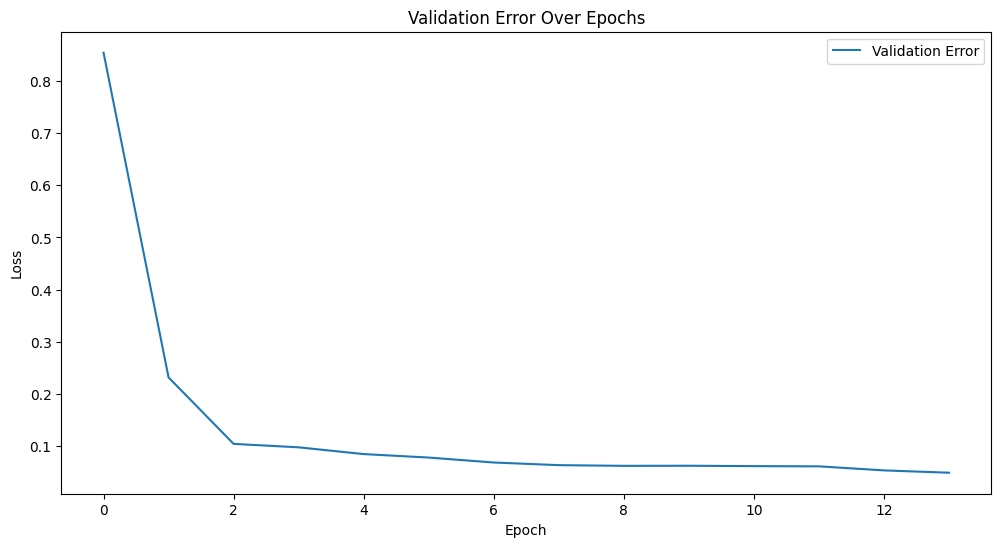

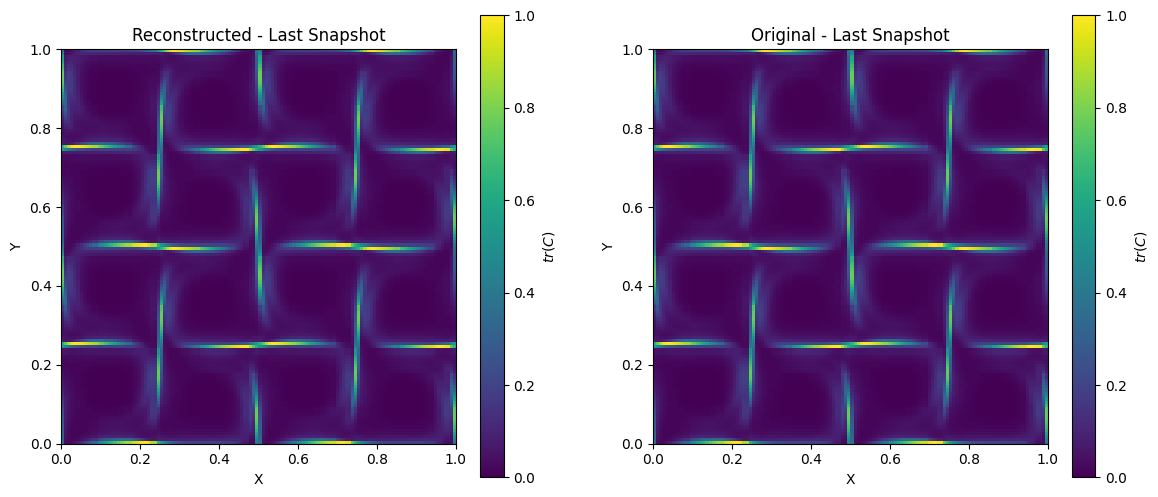

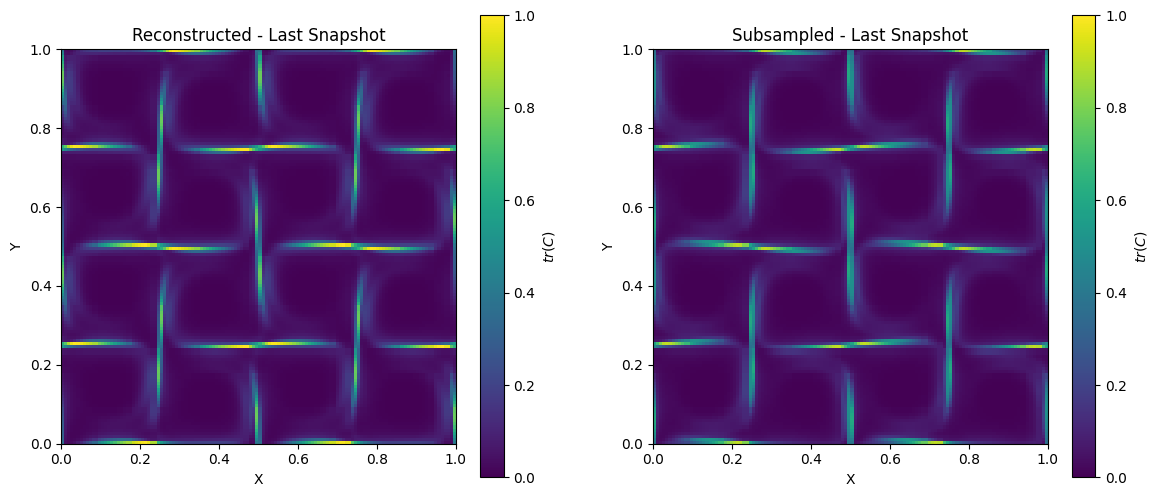

SSIM for the last snapshot: 0.999431542649733
MSE for the last snapshot: 0.021682830527424812
PSNR for the last snapshot: 48.9381739427504 dB
Normalized Error for the last snapshot: 0.021573342382907867
Mean SSIM for all snapshots: 0.9993491406998699
Mean PSNR for all snapshots: 49.30232872529314 dB
Mean Normalized Error for all snapshots: 0.020883463323116302
Results saved to /home/romulo/Documentos/lpips-env/results/shred/oldroyd_no_sub_paper/results.json
Plots saved to /home/romulo/Documentos/lpips-env/results/shred/oldroyd_no_sub_paper


In [20]:
plot_results(
  validation_errors,  test_recons, test_ground_truth, matrix, snapshot,save_path=save_path
)

In [21]:
import lpips
import json
import os

# Criando o modelo LPIPS
loss_fn = lpips.LPIPS(net='alex', use_dropout=True)  # ou 'vgg'

# Convertendo imagens para tensores e normalizando
img0 = torch.from_numpy(test_ground_truth).unsqueeze(0).float()  # Ground truth
img1 = torch.from_numpy(test_recons).unsqueeze(0).float()  # Reconstructed

# Avaliação da similaridade perceptual
d = loss_fn(img0, img1)

lpips_value = d.item()
print(f'LPIPS (perceptual loss): {lpips_value}')

# Carregando o arquivo JSON existente
json_file_path = os.path.join(save_path, "results.json")
with open(json_file_path, "r") as json_file:
    results = json.load(json_file)

# Adicionando a métrica LPIPS aos resultados
results["LPIPS"] = lpips_value

# Salvando o arquivo JSON atualizado
with open(json_file_path, "w") as json_file:
    json.dump(results, json_file, indent=4)

print(f"Resultados atualizados com LPIPS salvos em {json_file_path}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/romulo/Documentos/lpips-env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/romulo/Documentos/lpips-env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/romulo/Documentos/lpips-env/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
LPIPS (perceptual loss): 0.000328782363794744
Resultados atualizados com LPIPS salvos em /home/romulo/Documentos/lpips-env/results/shred/oldroyd_no_sub_paper/results.json
